In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss



**DATASET PROCESSING**

In [4]:
data = pd.read_csv("Breast_Cancer.csv")


data = data.dropna()


label_encoders = {}
for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le


**TRAINING**

In [5]:
X = data.drop("Status", axis=1)
y = data["Status"]

# data split (80, 20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Training
epochs = range(1, 21)
accuracy_list = []
loss_list = []

for epoch in epochs:

    model = DecisionTreeClassifier(criterion="gini", random_state=epoch, max_depth=None)


    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    acc = accuracy_score(y_val, y_pred)
    loss = log_loss(y_val, y_prob)

    accuracy_list.append(acc)
    loss_list.append(loss)

    print(f"Epoch {epoch}: Accuracy = {acc:.4f}, Log Loss = {loss:.4f}")


Epoch 1: Accuracy = 0.8087, Log Loss = 6.8953
Epoch 2: Accuracy = 0.8199, Log Loss = 6.4923
Epoch 3: Accuracy = 0.8112, Log Loss = 6.8058
Epoch 4: Accuracy = 0.8236, Log Loss = 6.3580
Epoch 5: Accuracy = 0.8149, Log Loss = 6.6714
Epoch 6: Accuracy = 0.8149, Log Loss = 6.6714
Epoch 7: Accuracy = 0.8161, Log Loss = 6.6267
Epoch 8: Accuracy = 0.8248, Log Loss = 6.3132
Epoch 9: Accuracy = 0.8161, Log Loss = 6.6267
Epoch 10: Accuracy = 0.8161, Log Loss = 6.6267
Epoch 11: Accuracy = 0.8286, Log Loss = 6.1789
Epoch 12: Accuracy = 0.8261, Log Loss = 6.2685
Epoch 13: Accuracy = 0.8137, Log Loss = 6.7162
Epoch 14: Accuracy = 0.8087, Log Loss = 6.8953
Epoch 15: Accuracy = 0.8124, Log Loss = 6.7610
Epoch 16: Accuracy = 0.8236, Log Loss = 6.3580
Epoch 17: Accuracy = 0.8062, Log Loss = 6.9849
Epoch 18: Accuracy = 0.8298, Log Loss = 6.1341
Epoch 19: Accuracy = 0.8161, Log Loss = 6.6267
Epoch 20: Accuracy = 0.8236, Log Loss = 6.3580


**PLOTS**

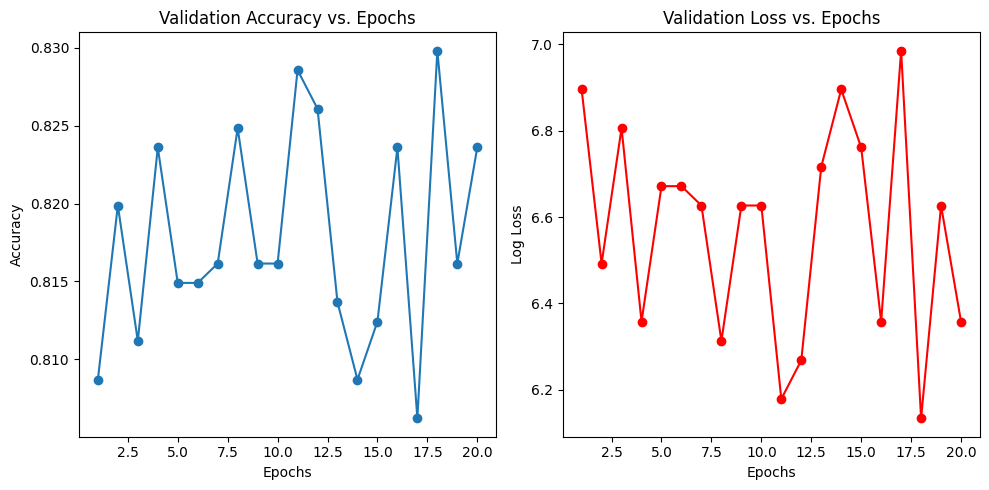

In [6]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy_list, marker='o')
plt.title("Validation Accuracy vs. Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs, loss_list, marker='o', color='red')
plt.title("Validation Loss vs. Epochs")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")

plt.tight_layout()
plt.show()


**DECISION TREE**

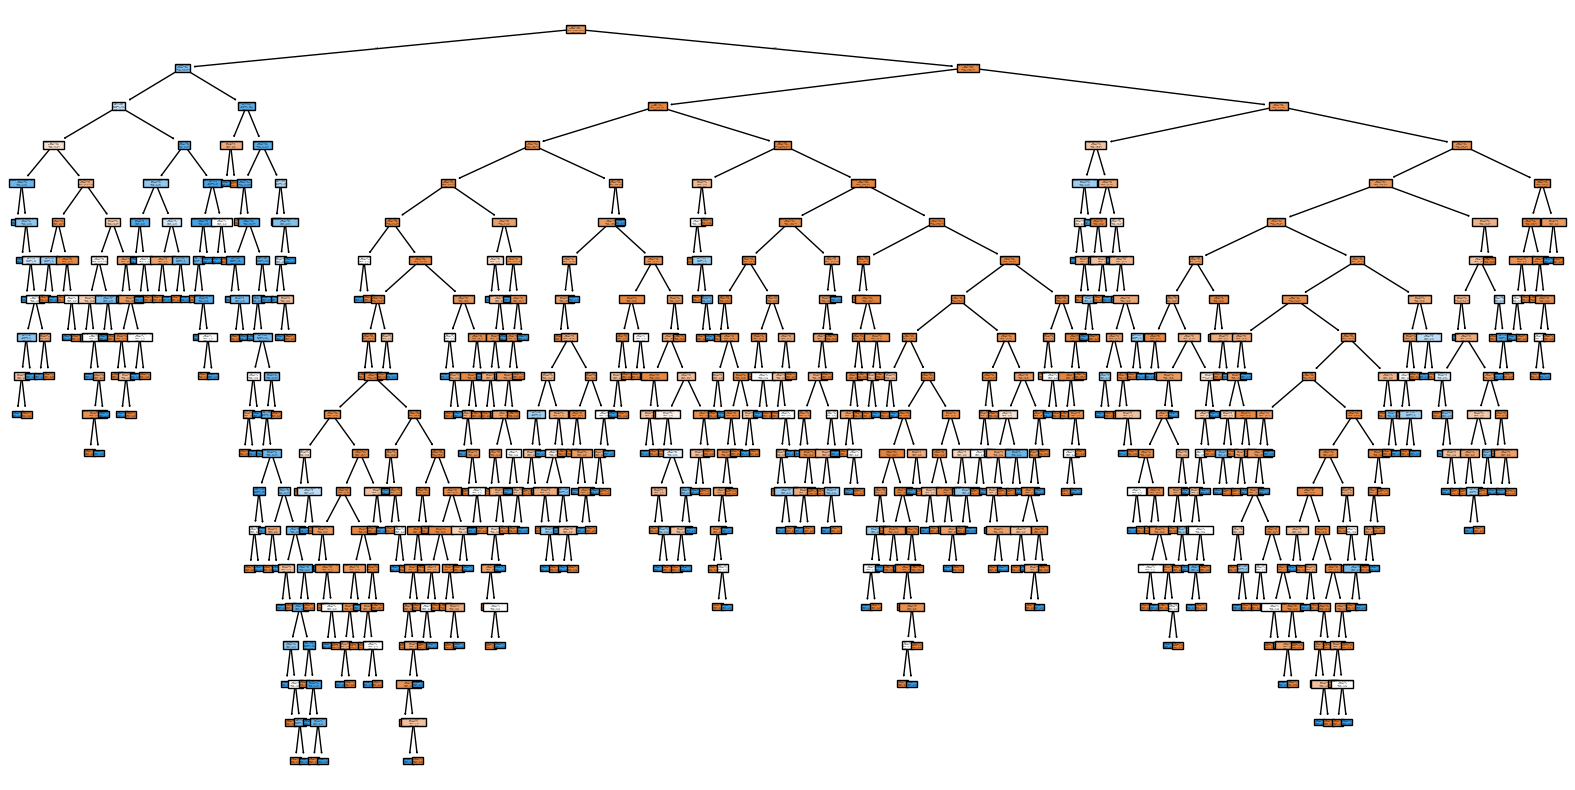

In [7]:
from sklearn import tree
plt.figure(figsize=(20, 10))
tree.plot_tree(model, filled=True, feature_names=X.columns, class_names=["Alive", "Dead"])
plt.show()